# Bacteria movement: run and tumble
## part 1

In [1]:
# relevant Python libraries
import sys
import numpy as np # numerical computing
import matplotlib.pyplot as plt # plotting
import pandas as pd # data handling
from pathlib import Path # file handling


import scipy.io as sio
import os

# custom functions
sys.path.append(os.path.abspath('../sandbox'))
import metrics

import warnings
warnings.filterwarnings("ignore")

# the code below autoloads new changes (no restart of the kernel needed)
%reload_ext autoreload
%autoreload 2

metrics.py loaded successfully.


In [2]:
os.getcwd() # this file is located here

'/Users/abdulibrahim/Documents/gitHub/teaching_SoSe26_mobHumAni_exercises/notebooks'

In [3]:
base_path = os.path.join("./")

ecoli_path = os.path.join(base_path, "../data", "EcoliTrajectories.mat")

print("Base path:", base_path)
print("E. coli path:", ecoli_path)

ecoli_mat = sio.loadmat(ecoli_path)

print("Keys in E. coli file:", list(ecoli_mat.keys()))

Base path: ./
E. coli path: ./../data/EcoliTrajectories.mat
Keys in E. coli file: ['__header__', '__version__', '__globals__', 'V_10min', 'V_3min', 'V_50min', 'V_7min', 'V_MeAsp1_0511', 'V_MeAsp1_0511_bulk', 'V_MeAsp2_0511', 'V_MeAsp2_0511_bulk', 'V_MeAsp3_0511', 'V_MeAsp3_0511_bulk', 'V_MeAspInverted_1mM_0512_bulk', 'V_MeAsp_0511', 'V_MeAsp_0511_bulk', 'V_MeAsp_0722', 'V_MeAsp_0722_bulk', 'V_MeAsp_0821', 'V_MeAsp_0821_bulk', 'V_MeAsp_1mM_0512_bulk', 'V_Reference_0503_bulk']


# Looking into the data

In [4]:
all_keys = list(ecoli_mat.keys())
dataset_keys = [k for k in all_keys if k.startswith('V_')]

dataset_keys

['V_10min',
 'V_3min',
 'V_50min',
 'V_7min',
 'V_MeAsp1_0511',
 'V_MeAsp1_0511_bulk',
 'V_MeAsp2_0511',
 'V_MeAsp2_0511_bulk',
 'V_MeAsp3_0511',
 'V_MeAsp3_0511_bulk',
 'V_MeAspInverted_1mM_0512_bulk',
 'V_MeAsp_0511',
 'V_MeAsp_0511_bulk',
 'V_MeAsp_0722',
 'V_MeAsp_0722_bulk',
 'V_MeAsp_0821',
 'V_MeAsp_0821_bulk',
 'V_MeAsp_1mM_0512_bulk',
 'V_Reference_0503_bulk']

In [5]:
# --------------
# parameters
# -------------

angle_threshold = 45 # angle change threshold for run/tumble classification (degrees)
V_10min = ecoli_mat['V_10min'] # our dataset for now
ref_t = np.logspace(-1.5, 1.5, 100)
# The crossover between the two happens at τ_c (correlation time).
tau_c = 1.6  # τ_c ≈ 1.6 s for wild-type E. coli (from lecture).

In [6]:
fps = float(V_10min['Parameters'][0, 0]['fps'][0, 0][0, 0])
dt  = 1.0 / fps
n_traj = len(V_10min['Speeds'][0, 0])
n_traj

150

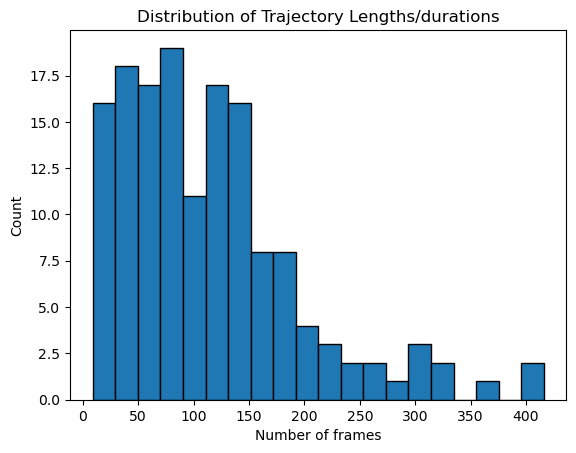

In [7]:
lengths = [len(V_10min['Speeds'][0,0][i][0]) for i in range(n_traj)]

plt.hist(lengths, bins=20, edgecolor='black')
plt.title("Distribution of Trajectory Lengths/durations")
plt.xlabel("Number of frames")
plt.ylabel("Count")
plt.show()

In [8]:
raw = V_10min['Speeds'][0, 0][0][0]

for col in range(raw.shape[1]):
    n_nan = np.sum(np.isnan(raw[:, col]))
    print(f"    col {col}: {n_nan} NaN frames")

    col 0: 0 NaN frames
    col 1: 0 NaN frames
    col 2: 0 NaN frames
    col 3: 0 NaN frames
    col 4: 0 NaN frames
    col 5: 2 NaN frames
    col 6: 2 NaN frames
    col 7: 2 NaN frames
    col 8: 2 NaN frames
    col 9: 6 NaN frames


In [9]:
# clean: keep only rows where ALL key columns are finite
key_cols  = [1, 2, 3, 5, 6, 7, 8, 9]   # x, y, z, speed, angle
valid     = np.all(np.isfinite(raw[:, key_cols]), axis=1)
n_dropped = (~valid).sum()
raw_clean = raw[valid]

In [10]:
raw.shape[0], raw_clean.shape[0]

(146, 140)

In [11]:
df = pd.DataFrame({
    'frame'           : raw_clean[:, 0].astype(int),
    'time_s'          : raw_clean[:, 0] / fps,
    'x_um'            : raw_clean[:, 1],
    'y_um'            : raw_clean[:, 2],
    'z_um'            : raw_clean[:, 3],
    'vx_um_s'         : raw_clean[:, 5],  
    'vy_um_s'         : raw_clean[:, 6],  
    'vz_um_s'         : raw_clean[:, 7],  
    'speed_um_s'      : raw_clean[:, 8],  
    'angle_change_deg': raw_clean[:, 9],  
}).reset_index(drop=True)


In [12]:
df

,frame,time_s,x_um,y_um,z_um,vx_um_s,vy_um_s,vz_um_s,speed_um_s,angle_change_deg
0,4,0.266667,89.100077,258.592708,-41.413207,9.206089,0.019106,-2.158903,9.455861,6.117073
1,5,0.333333,89.839966,258.593537,-41.558005,11.099129,0.005957,-2.158359,11.307043,12.674389
2,6,0.400000,90.579960,258.593502,-41.700988,11.100586,1.163334,-2.156907,11.367876,22.743116
3,7,0.466667,91.320044,258.748648,-41.845593,11.102052,3.763083,-2.159476,11.919719,27.963840
4,8,0.533333,92.060234,259.095246,-41.988918,9.782858,5.205981,-2.155944,11.289582,15.602570
...,...,...,...,...,...,...,...,...,...,...
135,139,9.266667,106.715440,227.903788,-92.459289,-4.326284,0.833863,-1.437248,4.634408,94.750498
136,140,9.333333,106.427141,227.532254,-92.611855,-4.324770,-5.581244,-6.705263,9.737273,92.071739
137,141,9.400000,106.138804,227.159622,-93.353324,-4.323579,-7.591686,-11.123020,14.143854,30.083122
138,142,9.466667,105.850664,226.520029,-94.094924,-4.322467,-9.898077,-7.232434,12.998606,39.883050
